# Debug & Testing Preliminare

Notebook per testare una singola combinazione **(problema, dimensione, metodo, parametri)** su tutti e 6 gli starting point.

**Uso:** edita solo la cella di configurazione, poi **Run All**.

In [ ]:
# CONFIGURAZIONE — edita solo questa cella

PROBLEM     = "P28"               # "P16" | "P28"
DIM         = 100_000               # dimensione n
METHOD      = "truncated_newton"  # "modified_newton" | "truncated_newton"

MAX_ITER    = 2_000                  # iterazioni esterne max
TIME_LIMIT  = 30                  # secondi (None = no limit)

# --- Stopping criterion ---------------------------------------------------
# "GradNormAbsolute" | "GradNormRelative"
# "FChangeAbsolute"  | "FChangeRelative"
# "XChangeAbsolute"  | "XChangeRelative"
# "combined"  (OR di tutti e 6)
STOPPING    = "GradNormAbsolute"
TOL_G       = 1e-3
TOL_F       = 1e-12
TOL_X       = 1e-8

# --- Gradiente -------------------------------------------------------------
GRAD_MODE      = "fd"          # "exact" | "fd"
GRAD_FD_K      = 8                # esponente h = 10^{-k}  (k in {4, 8, 12})
GRAD_FD_SCALED = True            # True: h_i = 10^{-k}*|x_i|

# --- Hessiana --------------------------------------------------------------
# "exact" -> hess_f16 / hess_f28
# "fd"    -> auto-dispatch in base a PROBLEM e METHOD:
#            modified_newton + P16 -> hess_fd_diag (CPR, hessiana diagonale)
#            modified_newton + P28 -> hess_fd col-by-col
#            truncated_newton      -> hv_fd matrix-free (hess_f=None)
HESS_MODE      = "fd"             # "exact" | "fd"
HESS_FD_K      = 8
HESS_FD_SCALED = True

# --- Line-search -----------------------------------------------------------
ALPHA0      = 1.0
C1          = 1e-4
RHO         = 0.5

# --- Parametri method-specific ---------------------------------------------
BETA            = 1e-3            # Modified Newton: soglia Cholesky
FORCING         = "quadratic"   # Truncated Newton: "linear" | "superlinear" | "quadratic"
CG_MAX_ITER     = 2*DIM            # Truncated Newton: None = n

SEED = min(346165, 323334)

In [59]:
import time
import numpy as np
import scipy.sparse as sp

from src.functions import f16, x_bar_16, f28, x_bar_28
from src.gradients import grad_f16, grad_f28, grad_fd
from src.hessians import hess_f16, hess_f28, hess_fd, hess_fd_diag, hv_fd
from src.methods import modified_newton, truncated_newton
from src.stopping_criteria import (
    GradNormAbsolute, GradNormRelative,
    FChangeAbsolute, FChangeRelative,
    XChangeAbsolute, XChangeRelative,
    all_criteria,
)
from src.stopping_criteria.base import StoppingCriterion
from src.starting_points import generate_starting_points

# ── Problema ──────────────────────────────────────────────
if PROBLEM == "P16":
    f_func, grad_exact, hess_exact, x_bar_func = f16, grad_f16, hess_f16, x_bar_16
elif PROBLEM == "P28":
    f_func, grad_exact, hess_exact, x_bar_func = f28, grad_f28, hess_f28, x_bar_28
else:
    raise ValueError(f"Problema sconosciuto: {PROBLEM!r}")

# ── Gradiente ─────────────────────────────────────────────
if GRAD_MODE == "exact":
    grad_func = grad_exact
elif GRAD_MODE == "fd":
    grad_func = lambda x: grad_fd(f_func, x, k=GRAD_FD_K, scaled=GRAD_FD_SCALED)
else:
    raise ValueError(f"GRAD_MODE sconosciuto: {GRAD_MODE!r}")

# ── Hessiana (auto-dispatch) ──────────────────────────────
# L'utente sceglie solo "exact" o "fd".
# La variante FD concreta viene scelta automaticamente:
#   - truncated_newton        -> hv_fd matrix-free (hess_f=None, k/scaled passati al metodo)
#   - modified_newton + P16   -> hess_fd_diag (CPR single-color, hessiana diagonale)
#   - modified_newton + P28   -> hess_fd col-by-col

hess_func = None

if HESS_MODE == "exact":
    hess_func = hess_exact
elif HESS_MODE == "fd":
    if METHOD == "truncated_newton":
        hess_func = None   # truncated_newton costruisce hv_fd internamente
    elif PROBLEM == "P16":
        hess_func = lambda x: sp.diags(
            hess_fd_diag(grad_func, x, k=HESS_FD_K, scaled=HESS_FD_SCALED))
    else:
        hess_func = lambda x: hess_fd(
            grad_func, x, k=HESS_FD_K, scaled=HESS_FD_SCALED)
else:
    raise ValueError(f"HESS_MODE sconosciuto: {HESS_MODE!r}")

# ── Starting points ───────────────────────────────────────
x_bar = x_bar_func(DIM)
rng = np.random.default_rng(SEED)
all_x0 = generate_starting_points(x_bar, num_random=5, rng=rng)

# ── Stopping criterion ────────────────────────────────────
_CRITERIA_MAP = {
    "GradNormAbsolute": lambda: GradNormAbsolute(TOL_G),
    "GradNormRelative": lambda: GradNormRelative(TOL_G),
    "FChangeAbsolute":  lambda: FChangeAbsolute(TOL_F),
    "FChangeRelative":  lambda: FChangeRelative(TOL_F),
    "XChangeAbsolute":  lambda: XChangeAbsolute(TOL_X),
    "XChangeRelative":  lambda: XChangeRelative(TOL_X),
}

class CombinedStopping(StoppingCriterion):
    """OR: si ferma quando un qualsiasi criterio interno scatta."""
    def __init__(self, criteria):
        self.criteria = criteria
        self.tol = None
        self._triggered = "max_iter"

    @property
    def name(self):
        return self._triggered

    def initialize(self, x0, F0, g0):
        for c in self.criteria:
            c.initialize(x0, F0, g0)

    def should_stop(self, k, x, F, g, x_prev, F_prev):
        for c in self.criteria:
            if c.should_stop(k, x, F, g, x_prev, F_prev):
                self._triggered = c.name
                return True
        return False

def _make_stopping():
    if STOPPING == "combined":
        return CombinedStopping(all_criteria(TOL_G, TOL_F, TOL_X))
    if STOPPING in _CRITERIA_MAP:
        return _CRITERIA_MAP[STOPPING]()
    raise ValueError(f"STOPPING sconosciuto: {STOPPING!r}")

# ── Summary ───────────────────────────────────────────────
grad_label = "exact" if GRAD_MODE == "exact" else f"fd(k={GRAD_FD_K}, scaled={GRAD_FD_SCALED})"
if HESS_MODE == "exact":
    hess_label = "exact"
elif METHOD == "truncated_newton":
    hess_label = f"hv_fd(k={HESS_FD_K}, scaled={HESS_FD_SCALED})"
elif PROBLEM == "P16":
    hess_label = f"fd_diag/CPR(k={HESS_FD_K}, scaled={HESS_FD_SCALED})"
else:
    hess_label = f"fd_col(k={HESS_FD_K}, scaled={HESS_FD_SCALED})"

print(f"Problema:    {PROBLEM}  (n = {DIM:,})")
print(f"Metodo:      {METHOD}")
print(f"Gradiente:   {grad_label}")
print(f"Hessiana:    {hess_label}")
print(f"Stopping:    {STOPPING}")
print(f"max_iter:    {MAX_ITER}")
print(f"time_limit:  {TIME_LIMIT}s")
print(f"Starting pts: {len(all_x0)} (x_bar + {len(all_x0)-1} random)")

Problema:    P28  (n = 100,000)
Metodo:      truncated_newton
Gradiente:   exact
Hessiana:    hv_fd(k=8, scaled=True)
Stopping:    GradNormAbsolute
max_iter:    2000
time_limit:  30s
Starting pts: 6 (x_bar + 5 random)


In [60]:
results = []

for idx, x0 in enumerate(all_x0):
    tag = "x_bar" if idx == 0 else f"rand_{idx}"
    stopping = _make_stopping()

    common_kw = dict(
        f=f_func, x0=x0, stopping=stopping,
        grad_f=grad_func,
        alpha0=ALPHA0, c1=C1, rho=RHO,
        max_iter=MAX_ITER, time_limit=TIME_LIMIT,
        return_history=True,
    )

    if METHOD == "modified_newton":
        if hess_func is None:
            raise ValueError("modified_newton requires hess_func (HESS_MODE='fd' con truncated_newton non vale qui)")
        res = modified_newton(**{**common_kw, 'hess_f': hess_func,
                                 'beta': BETA, 'max_iter_backtrack': 50})
    elif METHOD == "truncated_newton":
        tn_kw = {**common_kw, 'forcing': FORCING, 'max_iter_backtrack': 50,
                 'hess_f': hess_func}
        if CG_MAX_ITER is not None:
            tn_kw['cg_max_iter'] = CG_MAX_ITER
        if HESS_MODE == "fd" and hess_func is None:
            tn_kw['k'] = HESS_FD_K
            tn_kw['scaled'] = HESS_FD_SCALED
        res = truncated_newton(**tn_kw)
    else:
        raise ValueError(f"Unknown METHOD: {METHOD!r}")

    res['x0_idx'] = idx
    res['x0_tag'] = tag
    results.append(res)

    ok = "OK" if res['success'] else "NO"
    print(f"  x0[{idx}] ({tag:>6s}):  {ok}  {res['stop_reason']:<22s}  "
          f"iter={res['n_iter']:>4d}  f*={res['f_star']:+.6e}  "
          f"||g||={res['grad_norm']:.2e}  t={res['elapsed_s']:.2f}s")

print(f"\nConverged: {sum(r['success'] for r in results)}/{len(results)}")

  x0[0] ( x_bar):  NO  max_iter                iter=2000  f*=+6.173210e+37  ||g||=1.35e+36  t=13.61s
  x0[1] (rand_1):  NO  max_iter                iter=2000  f*=+6.133197e+37  ||g||=1.35e+36  t=13.46s
  x0[2] (rand_2):  NO  max_iter                iter=2000  f*=+6.090529e+37  ||g||=1.34e+36  t=13.92s
  x0[3] (rand_3):  NO  max_iter                iter=2000  f*=+6.215383e+37  ||g||=1.36e+36  t=14.45s
  x0[4] (rand_4):  NO  max_iter                iter=2000  f*=+6.164147e+37  ||g||=1.35e+36  t=18.50s
  x0[5] (rand_5):  NO  max_iter                iter=2000  f*=+6.086931e+37  ||g||=1.34e+36  t=24.05s

Converged: 0/6


In [50]:
# ── Tabella riassuntiva ────────────────────────────────────
hdr = f"{'idx':>3s}  {'tag':>6s}  {'ok':>2s}  {'stop_reason':<22s}  {'iter':>5s}  {'f_star':>14s}  {'||grad||':>10s}  {'time':>7s}"
extra_hdr = ""
if METHOD == "modified_newton":
    extra_hdr = f"  {'chol_adj':>8s}"
elif METHOD == "truncated_newton":
    extra_hdr = f"  {'cg_tot':>6s}  {'neg_c':>5s}"

print(hdr + extra_hdr)
print("-" * len(hdr + extra_hdr))

for r in results:
    ok = "OK" if r['success'] else "NO"
    row = (f"{r['x0_idx']:>3d}  {r['x0_tag']:>6s}  {ok:>2s}  {r['stop_reason']:<22s}  "
           f"{r['n_iter']:>5d}  {r['f_star']:>14.6e}  {r['grad_norm']:>10.2e}  "
           f"{r['elapsed_s']:>6.2f}s")
    if METHOD == "modified_newton":
        row += f"  {r.get('n_chol_adjustments_total', 0):>8d}"
    elif METHOD == "truncated_newton":
        row += f"  {r.get('cg_iters_total', 0):>6d}  {r.get('neg_curvature_count', 0):>5d}"
    print(row)

idx     tag  ok  stop_reason              iter          f_star    ||grad||     time  cg_tot  neg_c
--------------------------------------------------------------------------------------------------
  0   x_bar  NO  max_iter                 2000    6.173210e+37    1.35e+36   13.72s    2000      0
  1  rand_1  NO  max_iter                 2000    6.133197e+37    1.35e+36   12.99s    2000      0
  2  rand_2  NO  max_iter                 2000    6.090529e+37    1.34e+36   13.99s    2000      0
  3  rand_3  NO  max_iter                 2000    6.215383e+37    1.36e+36   16.11s    2000      0
  4  rand_4  NO  max_iter                 2000    6.164147e+37    1.35e+36   14.28s    2000      0
  5  rand_5  NO  max_iter                 2000    6.086931e+37    1.34e+36   16.73s    2000      0


## Diagnostiche per-iterazione

Scegli quale starting point ispezionare in dettaglio settando `INSPECT_X0`.

In [51]:
INSPECT_X0 = 1  # quale starting point ispezionare (0 = x_bar, 1..5 = random)

In [52]:
# ── Result summary per x0 scelto ──────────────────────────
r = results[INSPECT_X0]
print("=" * 60)
print(f"DETTAGLIO  x0[{INSPECT_X0}] ({r['x0_tag']})")
print("=" * 60)
print(f"  success:     {r['success']}")
print(f"  stop_reason: {r['stop_reason']}")
print(f"  n_iter:      {r['n_iter']}")
print(f"  f_star:      {r['f_star']:.10e}")
print(f"  ||grad||:    {r['grad_norm']:.6e}")
print(f"  elapsed:     {r['elapsed_s']:.2f}s")
if 'n_chol_adjustments_total' in r:
    print(f"  chol_adj:    {r['n_chol_adjustments_total']}")
if 'cg_iters_total' in r:
    print(f"  cg_iters:    {r['cg_iters_total']}")
if 'neg_curvature_count' in r:
    print(f"  neg_curv:    {r['neg_curvature_count']}")

xs = r['x_star']
if len(xs) <= 10:
    print(f"  x_star:      {xs}")
else:
    print(f"  x_star[:5]:  {xs[:5]}")
    print(f"  x_star[-5:]: {xs[-5:]}")
print("=" * 60)

# ── Tabella per-iterazione ────────────────────────────────
history = r.get('history', [])
if not history:
    print("\nNo history disponibile.")
else:
    is_mn = METHOD == "modified_newton"
    is_tn = METHOD == "truncated_newton"

    hdr = f"{'k':>4s}  {'f(x)':>14s}  {'||grad||':>12s}  {'alpha':>10s}  {'||step||':>10s}"
    if is_mn:
        hdr += f"  {'tau':>10s}"
    if is_tn:
        hdr += f"  {'cg_j':>5s}  {'eta_k':>8s}  {'cg_term':>12s}"
    print(f"\n{hdr}")
    print("-" * len(hdr))

    for k, h in enumerate(history):
        alpha_str = f"{h['alpha']:.2e}" if h.get('alpha') is not None else "     -"
        f_str = f"{h['f']:14.6e}"
        g_str = f"{h['grad_norm']:12.4e}"

        if h.get('p_norm') is not None:
            step_str = f"{h['p_norm']:10.2e}"
        else:
            step_str = "         -"

        row = f"{k:>4d}  {f_str}  {g_str}  {alpha_str:>10s}  {step_str:>10s}"

        if is_mn:
            tau_str = f"{h['tau']:.2e}" if h.get('tau') is not None else "     -"
            row += f"  {tau_str:>10s}"
        if is_tn:
            cg_str = str(h['cg_iters']) if h.get('cg_iters') is not None else "-"
            eta_str = f"{h['nu_k']:.4f}" if h.get('nu_k') is not None else "   -"
            term_str = h.get('cg_termination') or "-"
            row += f"  {cg_str:>5s}  {eta_str:>8s}  {term_str:>12s}"

        print(row)

DETTAGLIO  x0[1] (rand_1)
  success:     False
  stop_reason: max_iter
  n_iter:      2000
  f_star:      6.1331966478e+37
  ||grad||:    1.345892e+36
  elapsed:     12.99s
  cg_iters:    2000
  neg_curv:    0
  x_star[:5]:  [1.49558035 0.73716835 0.20717778 0.95228597 1.35574343]
  x_star[-5:]: [ 0.52526099  0.77626385  0.72642958 -0.15929741 -0.54329079]

   k            f(x)      ||grad||       alpha    ||step||   cg_j     eta_k       cg_term
-----------------------------------------------------------------------------------------
   0    6.133197e+37    1.3459e+36           -           -      -         -             -
   1    6.133197e+37    1.3459e+36    1.00e+00    8.39e-51      1    0.5000           tol
   2    6.133197e+37    1.3459e+36    1.00e+00    8.39e-51      1    0.5000           tol
   3    6.133197e+37    1.3459e+36    1.00e+00    8.39e-51      1    0.5000           tol
   4    6.133197e+37    1.3459e+36    1.00e+00    8.39e-51      1    0.5000           tol
   5    6.

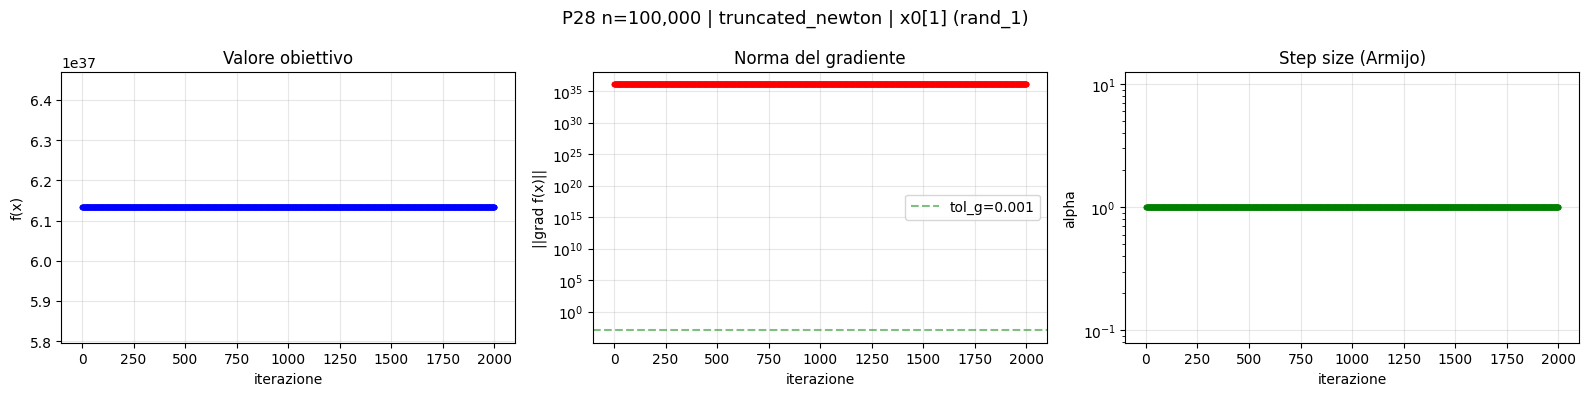

In [53]:
import matplotlib.pyplot as plt

history = results[INSPECT_X0].get('history', [])
if len(history) < 2:
    print("Non abbastanza iterazioni per i grafici.")
else:
    iters = list(range(len(history)))
    f_vals = [h['f'] for h in history]
    g_norms = [h['grad_norm'] for h in history]
    alphas = [h['alpha'] for h in history[1:]]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(iters, f_vals, 'b.-')
    axes[0].set_xlabel('iterazione')
    axes[0].set_ylabel('f(x)')
    axes[0].set_title('Valore obiettivo')
    axes[0].grid(True, alpha=0.3)

    axes[1].semilogy(iters, g_norms, 'r.-')
    axes[1].axhline(TOL_G, color='green', ls='--', alpha=0.5, label=f'tol_g={TOL_G}')
    axes[1].set_xlabel('iterazione')
    axes[1].set_ylabel('||grad f(x)||')
    axes[1].set_title('Norma del gradiente')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].semilogy(range(1, len(history)), alphas, 'g.-')
    axes[2].set_xlabel('iterazione')
    axes[2].set_ylabel('alpha')
    axes[2].set_title('Step size (Armijo)')
    axes[2].grid(True, alpha=0.3)

    tag = results[INSPECT_X0]['x0_tag']
    fig.suptitle(f'{PROBLEM} n={DIM:,} | {METHOD} | x0[{INSPECT_X0}] ({tag})', fontsize=13)
    plt.tight_layout()
    plt.show()

In [54]:
# ── Stima empirica del rate di convergenza ────────────────
g_norms = [h['grad_norm'] for h in results[INSPECT_X0].get('history', [])
           if h['grad_norm'] > 0]

if len(g_norms) >= 3:
    ratios_lin = [g_norms[i+1] / g_norms[i]
                  for i in range(len(g_norms)-1) if g_norms[i] > 1e-15]
    ratios_quad = [g_norms[i+1] / g_norms[i]**2
                   for i in range(len(g_norms)-1) if g_norms[i] > 1e-15]

    print("Ultime 5 ratio lineari   ||g_{k+1}||/||g_k||:     ",
          [f"{r:.4f}" for r in ratios_lin[-5:]])
    print("Ultime 5 ratio quadratiche ||g_{k+1}||/||g_k||^2: ",
          [f"{r:.4f}" for r in ratios_quad[-5:]])
else:
    print("Dati insufficienti per stimare il rate.")

Ultime 5 ratio lineari   ||g_{k+1}||/||g_k||:      ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
Ultime 5 ratio quadratiche ||g_{k+1}||/||g_k||^2:  ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
